# Trade Behaviour Risk & Anomaly Detection — Exploratory Data Analysis

Investigating trade behavior patterns, corridor dynamics, anomalies, and temporal properties across bilateral trade data.

## Setup & Imports

In [1]:
import sys
import os
from pathlib import Path

# Project path
PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

from src.trade_anomaly.data_loader import load_trade_anomaly_data, get_dataset_coverage

## Loading Dataset

In [2]:
df = load_trade_anomaly_data()

## Initial Inspection

In [3]:
df.head()

,period,reporter_iso3,partner_iso3,hs6,trade_flow,trade_value_usd,net_weight_kg,quantity,quantity_unit,product_description,...,partner_share_pct,partner_share_change_mom,new_corridor_flag,mirror_trade_value,mirror_ratio,mirror_difference,mirror_missing_flag,anomaly_type,anomaly_flag,label_source
0,202201,IND,ARE,90411,Export,83478703.89,14044282.94,14044282.94,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0006,NaN,1,83478703.89,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
1,202202,IND,ARE,90411,Export,70639786.07,12795865.37,12795865.37,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0005,-0.0001,0,70639786.07,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
2,202203,IND,ARE,90411,Export,74385065.51,13869833.37,13869833.37,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0007,0.0002,0,74385065.51,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
3,202204,IND,ARE,90411,Export,61384120.72,11367068.29,11367068.29,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0006,-0.0001,0,61384120.72,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
4,202205,IND,ARE,90411,Export,67043765.23,12243364.10,12243364.10,kg,Pepper of the genus Piper; neither crushed nor...,...,0.0006,0.0000,0,67043765.23,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC


In [4]:
df.tail()

,period,reporter_iso3,partner_iso3,hs6,trade_flow,trade_value_usd,net_weight_kg,quantity,quantity_unit,product_description,...,partner_share_pct,partner_share_change_mom,new_corridor_flag,mirror_trade_value,mirror_ratio,mirror_difference,mirror_missing_flag,anomaly_type,anomaly_flag,label_source
12283,202508,IND,ZAF,851712,Import,1.706608e+07,599567.49,599567.49,kg,Telephones for cellular networks / smartphones,...,0.0001,0.0001,0,1.706608e+07,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
12284,202509,IND,ZAF,851712,Import,1.314277e+08,3516808.11,3516808.11,kg,Telephones for cellular networks / smartphones,...,0.0010,0.0009,0,1.314277e+08,1.0,0.0,0,VOLUME_SURGE,1,RULE_BASED_HEURISTIC
12285,202510,IND,ZAF,851712,Import,2.256689e+06,72606.69,72606.69,kg,Telephones for cellular networks / smartphones,...,0.0000,-0.0010,0,2.256689e+06,1.0,0.0,0,UNEXPECTED_COLLAPSE,1,RULE_BASED_HEURISTIC
12286,202511,IND,ZAF,851712,Import,2.704767e+07,990723.94,990723.94,kg,Telephones for cellular networks / smartphones,...,0.0002,0.0002,0,2.704767e+07,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC
12287,202512,IND,ZAF,851712,Import,1.659218e+07,762056.03,762056.03,kg,Telephones for cellular networks / smartphones,...,0.0001,-0.0001,0,1.659218e+07,1.0,0.0,0,NORMAL,0,RULE_BASED_HEURISTIC


In [5]:
df.shape

(12288, 29)

In [6]:
df.columns.tolist()

['period',
 'reporter_iso3',
 'partner_iso3',
 'hs6',
 'trade_flow',
 'trade_value_usd',
 'net_weight_kg',
 'quantity',
 'quantity_unit',
 'product_description',
 'transaction_count',
 'unit_value_usd_per_kg',
 'trade_growth_mom',
 'unit_value_change_mom',
 'quantity_growth_mom',
 'weight_growth_mom',
 'yoy_growth',
 'rolling_mean_3m',
 'rolling_std_3m',
 'partner_share_pct',
 'partner_share_change_mom',
 'new_corridor_flag',
 'mirror_trade_value',
 'mirror_ratio',
 'mirror_difference',
 'mirror_missing_flag',
 'anomaly_type',
 'anomaly_flag',
 'label_source']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12288 entries, 0 to 12287
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   period                    12288 non-null  int64  
 1   reporter_iso3             12288 non-null  str    
 2   partner_iso3              12288 non-null  str    
 3   hs6                       12288 non-null  int64  
 4   trade_flow                12288 non-null  str    
 5   trade_value_usd           12288 non-null  float64
 6   net_weight_kg             12288 non-null  float64
 7   quantity                  12288 non-null  float64
 8   quantity_unit             12288 non-null  str    
 9   product_description       12288 non-null  str    
 10  transaction_count         12288 non-null  int64  
 11  unit_value_usd_per_kg     12288 non-null  float64
 12  trade_growth_mom          12032 non-null  float64
 13  unit_value_change_mom     12032 non-null  float64
 14  quantity_growth_m

In [8]:
df.dtypes

period                        int64
reporter_iso3                   str
partner_iso3                    str
hs6                           int64
trade_flow                      str
trade_value_usd             float64
net_weight_kg               float64
quantity                    float64
quantity_unit                   str
product_description             str
transaction_count             int64
unit_value_usd_per_kg       float64
trade_growth_mom            float64
unit_value_change_mom       float64
quantity_growth_mom         float64
weight_growth_mom           float64
yoy_growth                  float64
rolling_mean_3m             float64
rolling_std_3m              float64
partner_share_pct           float64
partner_share_change_mom    float64
new_corridor_flag             int64
mirror_trade_value          float64
mirror_ratio                float64
mirror_difference           float64
mirror_missing_flag           int64
anomaly_type                    str
anomaly_flag                

## Data Quality & Missing Value Checks

In [9]:
df.isnull().sum()

period                         0
reporter_iso3                  0
partner_iso3                   0
hs6                            0
trade_flow                     0
trade_value_usd                0
net_weight_kg                  0
quantity                       0
quantity_unit                  0
product_description            0
transaction_count              0
unit_value_usd_per_kg          0
trade_growth_mom             256
unit_value_change_mom        256
quantity_growth_mom          256
weight_growth_mom            256
yoy_growth                  3072
rolling_mean_3m              256
rolling_std_3m               512
partner_share_pct              0
partner_share_change_mom     256
new_corridor_flag              0
mirror_trade_value             0
mirror_ratio                   0
mirror_difference              0
mirror_missing_flag            0
anomaly_type                   0
anomaly_flag                   0
label_source                   0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

period                         48
reporter_iso3                   1
partner_iso3                   16
hs6                             8
trade_flow                      2
trade_value_usd             12288
net_weight_kg               12288
quantity                    12288
quantity_unit                   1
product_description            16
transaction_count               4
unit_value_usd_per_kg       10964
trade_growth_mom             9051
unit_value_change_mom        4684
quantity_growth_mom          8999
weight_growth_mom            8999
yoy_growth                   7473
rolling_mean_3m             12032
rolling_std_3m              11776
partner_share_pct            1821
partner_share_change_mom     1752
new_corridor_flag               2
mirror_trade_value          12288
mirror_ratio                    1
mirror_difference               1
mirror_missing_flag             1
anomaly_type                    3
anomaly_flag                    2
label_source                    1
dtype: int64

In [12]:
df.describe()

,period,hs6,trade_value_usd,net_weight_kg,quantity,transaction_count,unit_value_usd_per_kg,trade_growth_mom,unit_value_change_mom,quantity_growth_mom,...,rolling_mean_3m,rolling_std_3m,partner_share_pct,partner_share_change_mom,new_corridor_flag,mirror_trade_value,mirror_ratio,mirror_difference,mirror_missing_flag,anomaly_flag
count,12288.000000,12288.000000,1.228800e+04,1.228800e+04,1.228800e+04,12288.000000,12288.000000,12032.000000,12032.000000,12032.000000,...,1.203200e+04,1.177600e+04,12288.000000,1.203200e+04,12288.000000,1.228800e+04,12288.0,12288.0,12288.0,12288.000000
mean,202356.500000,461652.875000,4.763033e+10,8.560045e+06,8.560045e+06,5.000000,5562.727162,0.579855,0.013012,0.548835,...,4.780441e+10,1.063650e+10,0.390623,1.163564e-07,0.020833,4.763033e+10,1.0,0.0,0.0,0.093180
std,111.861231,295183.380593,1.630630e+11,6.755931e+06,6.755931e+06,3.553312,14675.453633,3.043156,0.169908,2.856741,...,1.607758e+11,3.612991e+10,1.328335,3.860853e-01,0.142832,1.630630e+11,0.0,0.0,0.0,0.290697
min,202201.000000,90411.000000,5.837795e+04,3.198014e+04,3.198014e+04,1.000000,0.780700,-0.987900,-0.584600,-0.986600,...,1.279982e+05,1.916385e+04,0.000000,-4.336500e+00,0.000000,5.837795e+04,1.0,0.0,0.0,0.000000
25%,202278.750000,228421.750000,1.062214e+07,1.616569e+06,1.616569e+06,1.000000,2.764575,-0.285950,-0.059100,-0.278550,...,1.137690e+07,3.149527e+06,0.000100,-1.000000e-04,0.000000,1.062214e+07,1.0,0.0,0.0,0.000000
50%,202356.500000,410501.000000,5.358042e+07,9.946285e+06,9.946285e+06,7.500000,7.503300,-0.007500,-0.000300,-0.005000,...,5.559292e+07,1.318424e+07,0.000400,0.000000e+00,0.000000,5.358042e+07,1.0,0.0,0.0,0.000000
75%,202434.250000,745271.750000,4.189521e+08,1.426110e+07,1.426110e+07,8.000000,71.029700,0.392225,0.061800,0.378525,...,4.204633e+08,1.262646e+08,0.003400,1.000000e-04,0.000000,4.189521e+08,1.0,0.0,0.0,0.000000
max,202512.000000,851712.000000,1.101525e+12,2.675311e+07,2.675311e+07,9.000000,53999.215700,70.406400,1.528300,66.017200,...,9.888155e+11,3.453799e+11,9.395300,4.269200e+00,1.000000,1.101525e+12,1.0,0.0,0.0,1.000000


## Inspecting Corridor & Entity Coverage

In [13]:
coverage = get_dataset_coverage(df)
print('Partners (16):', coverage['partners'])
print('HS6 Codes (8):', coverage['hs6_codes'])
print('Trade Flows (2):', coverage['trade_flows'])
print('Period Range:', coverage['min_period'], 'to', coverage['max_period'], f"({coverage['total_periods']} months)")
print('Total Corridors:', coverage['total_corridors'])

Partners (16): ['ARE', 'AUS', 'BRA', 'CHN', 'DEU', 'GBR', 'IDN', 'IND', 'JPN', 'KOR', 'NLD', 'SAU', 'SGP', 'USA', 'WLD', 'ZAF']
HS6 Codes (8): [90411, 100630, 271019, 300490, 520512, 711319, 847130, 851712]
Trade Flows (2): ['Export', 'Import']
Period Range: 202201 to 202512 (48 months)
Total Corridors: 256


In [14]:
df['trade_flow'].value_counts()

trade_flow
Export    6144
Import    6144
Name: count, dtype: int64

In [15]:
df['partner_iso3'].value_counts()

partner_iso3
ARE    768
AUS    768
BRA    768
CHN    768
DEU    768
GBR    768
IDN    768
IND    768
JPN    768
KOR    768
NLD    768
SAU    768
SGP    768
USA    768
WLD    768
ZAF    768
Name: count, dtype: int64

In [16]:
df['hs6'].value_counts()

hs6
90411     1536
100630    1536
271019    1536
300490    1536
520512    1536
711319    1536
847130    1536
851712    1536
Name: count, dtype: int64

## Exploring Anomaly Labels

In [17]:
df['anomaly_flag'].value_counts(normalize=True) * 100

anomaly_flag
0    90.681966
1     9.318034
Name: proportion, dtype: float64

In [18]:
df['anomaly_type'].value_counts()

anomaly_type
NORMAL                 11143
VOLUME_SURGE             949
UNEXPECTED_COLLAPSE      196
Name: count, dtype: int64

In [19]:
df['label_source'].value_counts()

label_source
RULE_BASED_HEURISTIC    12288
Name: count, dtype: int64

### Anomaly Class Distribution & Timeline

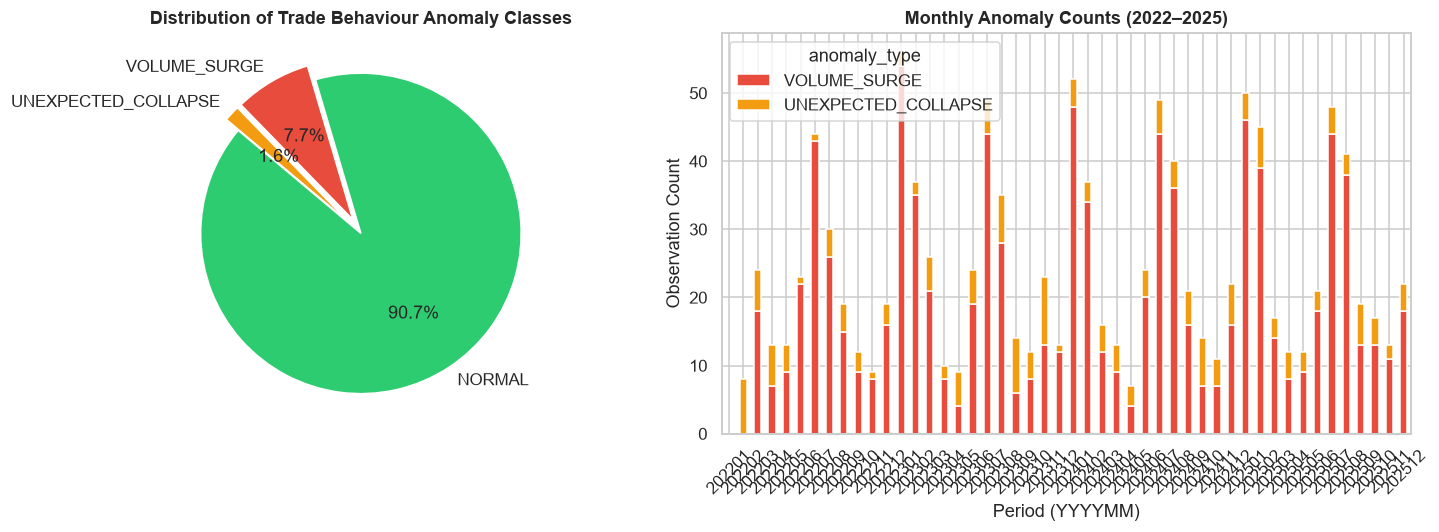

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df['anomaly_type'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
ax1.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0, 0.1, 0.1))
ax1.set_title('Distribution of Trade Behaviour Anomaly Classes', fontsize=12, fontweight='bold')

monthly_anomalies = df.groupby(['period', 'anomaly_type']).size().unstack(fill_value=0)
monthly_anomalies[['VOLUME_SURGE', 'UNEXPECTED_COLLAPSE']].plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#f39c12'])
ax2.set_title('Monthly Anomaly Counts (2022–2025)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Period (YYYYMM)')
ax2.set_ylabel('Observation Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Breakdown by Trade Flow & Commodity

In [21]:
df.groupby(['trade_flow', 'anomaly_type']).size().unstack(fill_value=0)

anomaly_type,NORMAL,UNEXPECTED_COLLAPSE,VOLUME_SURGE
trade_flow,,,
Export,5618,96,430
Import,5525,100,519


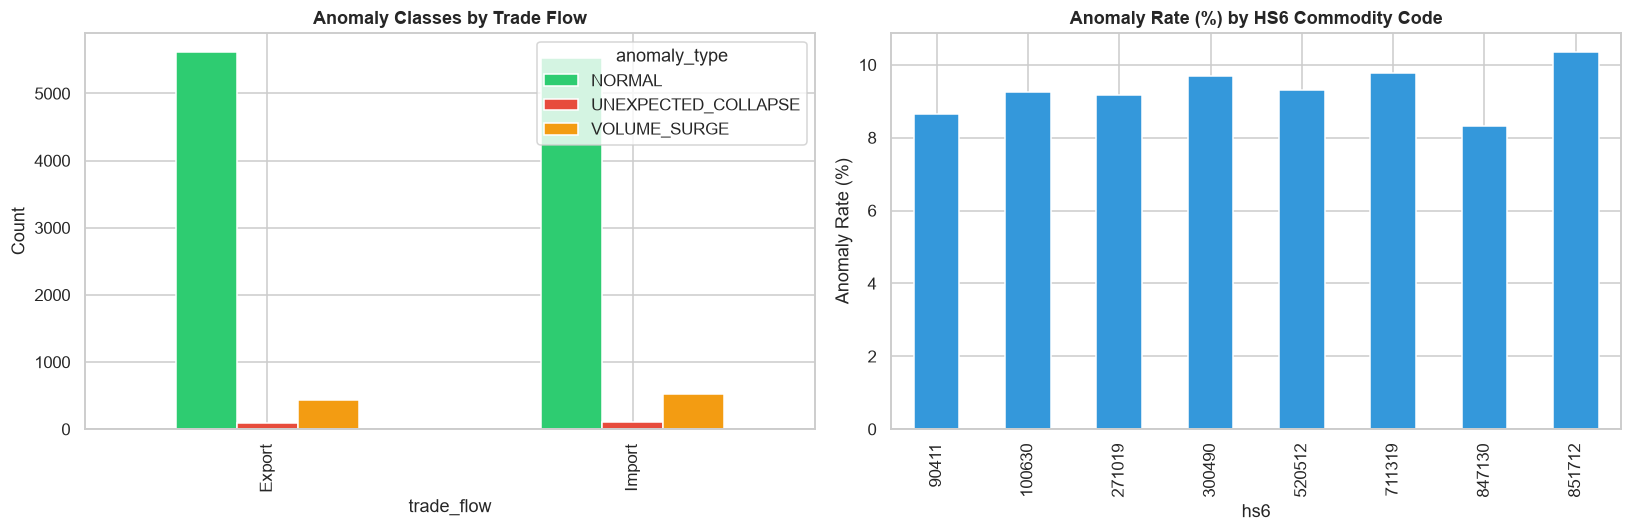

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

flow_summary = df.groupby(['trade_flow', 'anomaly_type']).size().unstack(fill_value=0)
flow_summary.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c', '#f39c12'])
ax1.set_title('Anomaly Classes by Trade Flow', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')

prod_rate = df.groupby('hs6')['anomaly_flag'].mean() * 100
prod_rate.plot(kind='bar', ax=ax2, color='#3498db')
ax2.set_title('Anomaly Rate (%) by HS6 Commodity Code', fontsize=12, fontweight='bold')
ax2.set_ylabel('Anomaly Rate (%)')
plt.tight_layout()
plt.show()

## Examining Corridor Trajectories

In [23]:
sample_corridor = df[(df['partner_iso3'] == 'ARE') & (df['hs6'] == 100630) & (df['trade_flow'] == 'Export')].sort_values('period')
sample_corridor[['period', 'trade_value_usd', 'quantity', 'trade_growth_mom', 'anomaly_type']].head(10)

,period,trade_value_usd,quantity,trade_growth_mom,anomaly_type
96,202201,21126047.53,16782986.67,NaN,NORMAL
97,202202,25776527.96,19331381.77,0.2201,NORMAL
98,202203,17499804.28,13917437.41,-0.3211,NORMAL
99,202204,13918545.59,11409789.18,-0.2046,NORMAL
100,202205,13234922.93,10812569.00,-0.0491,NORMAL
101,202206,18551081.40,14123951.83,0.4017,NORMAL
102,202207,19331347.67,15181911.96,0.0421,NORMAL
103,202208,22443580.88,17515560.86,0.1610,NORMAL
104,202209,22238179.08,17447774.89,-0.0092,NORMAL
105,202210,19510130.14,15070373.95,-0.1227,NORMAL


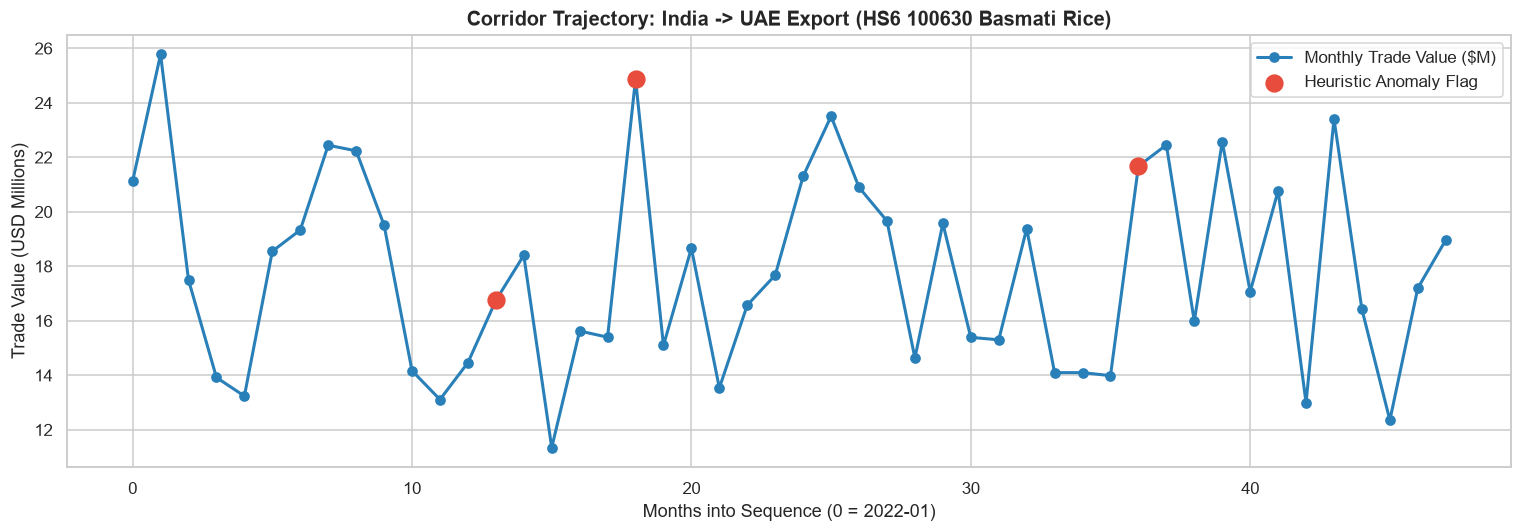

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(range(len(sample_corridor)), sample_corridor['trade_value_usd'] / 1e6, label='Monthly Trade Value ($M)', color='#2980b9', lw=2, marker='o')

anom_pts = sample_corridor[sample_corridor['anomaly_flag'] == 1]
plt.scatter(anom_pts.index - sample_corridor.index[0], anom_pts['trade_value_usd'] / 1e6, color='#e74c3c', s=120, zorder=5, label='Heuristic Anomaly Flag')

plt.title('Corridor Trajectory: India -> UAE Export (HS6 100630 Basmati Rice)', fontsize=13, fontweight='bold')
plt.xlabel('Months into Sequence (0 = 2022-01)')
plt.ylabel('Trade Value (USD Millions)')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Relationships & Collinearity

In [25]:
numeric_cols = [
    'trade_value_usd', 'net_weight_kg', 'quantity', 'unit_value_usd_per_kg',
    'trade_growth_mom', 'unit_value_change_mom', 'quantity_growth_mom',
    'weight_growth_mom', 'yoy_growth', 'rolling_mean_3m', 'rolling_std_3m',
    'partner_share_pct', 'partner_share_change_mom', 'new_corridor_flag', 'anomaly_flag'
]
df[numeric_cols].head()

,trade_value_usd,net_weight_kg,quantity,unit_value_usd_per_kg,trade_growth_mom,unit_value_change_mom,quantity_growth_mom,weight_growth_mom,yoy_growth,rolling_mean_3m,rolling_std_3m,partner_share_pct,partner_share_change_mom,new_corridor_flag,anomaly_flag
0,83478703.89,14044282.94,14044282.94,5.9440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0006,NaN,1,0
1,70639786.07,12795865.37,12795865.37,5.5205,-0.1538,-0.0712,-0.0889,-0.0889,NaN,83478703.89,NaN,0.0005,-0.0001,0,0
2,74385065.51,13869833.37,13869833.37,5.3631,0.0530,-0.0285,0.0839,0.0839,NaN,77059244.98,9078485.85,0.0007,0.0002,0,0
3,61384120.72,11367068.29,11367068.29,5.4002,-0.1748,0.0069,-0.1804,-0.1804,NaN,76167851.82,6602514.52,0.0006,-0.0001,0,0
4,67043765.23,12243364.10,12243364.10,5.4759,0.0922,0.0140,0.0771,0.0771,NaN,68802990.77,6692271.97,0.0006,0.0000,0,0


In [26]:
corr_matrix = df[numeric_cols].corr()
corr_matrix[['trade_value_usd', 'quantity', 'trade_growth_mom', 'anomaly_flag']]

,trade_value_usd,quantity,trade_growth_mom,anomaly_flag
trade_value_usd,1.000000,0.232791,-0.033374,0.028584
net_weight_kg,0.232791,1.000000,-0.129565,0.042414
quantity,0.232791,1.000000,-0.129565,0.042414
unit_value_usd_per_kg,0.756377,0.000133,-0.010572,0.006785
trade_growth_mom,-0.033374,-0.129565,1.000000,0.114832
unit_value_change_mom,-0.012633,-0.054324,0.131397,0.055836
quantity_growth_mom,-0.032804,-0.129370,0.971236,0.107831
weight_growth_mom,-0.032804,-0.129370,0.971236,0.107831
yoy_growth,-0.033493,-0.136601,0.131997,0.046213
rolling_mean_3m,0.957227,0.204104,-0.048960,-0.013399


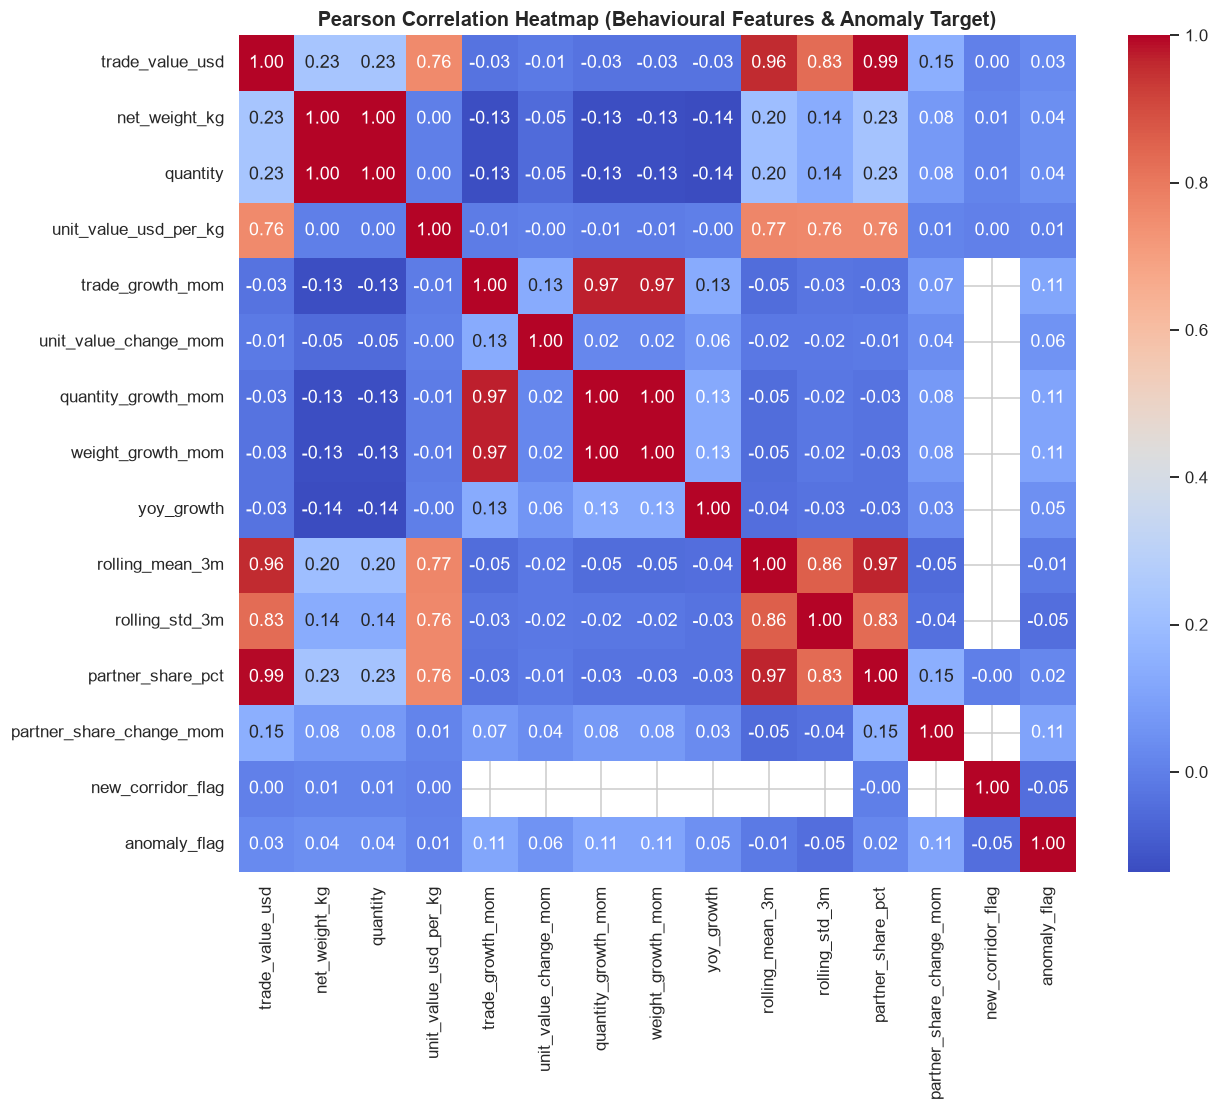

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title('Pearson Correlation Heatmap (Behavioural Features & Anomaly Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Takeaways from EDA

- `quantity` and `net_weight_kg` exhibit perfect collinearity (1.00 correlation).
- The anomaly labels (`VOLUME_SURGE`, `UNEXPECTED_COLLAPSE`) represent 9.32% of observations.
- Causal rolling features must be computed out-of-time (lagged $[t-3, t-1]$) to avoid forward-looking target leakage.
- Chronological partitioning: Train (2022-01 to 2024-06), Validation (2024-07 to 2024-12), Test (2025-01 to 2025-12).